Epoch 1: Val Loss: 0.2014, Val Acc: 0.9404
Epoch 2: Val Loss: 0.1378, Val Acc: 0.9593
Epoch 3: Val Loss: 0.1277, Val Acc: 0.9626
Epoch 4: Val Loss: 0.1331, Val Acc: 0.9607
Epoch 5: Val Loss: 0.1185, Val Acc: 0.9648
Epoch 6: Val Loss: 0.1099, Val Acc: 0.9676
Epoch 7: Val Loss: 0.1045, Val Acc: 0.9708
Epoch 8: Val Loss: 0.1080, Val Acc: 0.9702
Epoch 9: Val Loss: 0.1073, Val Acc: 0.9696
Epoch 10: Val Loss: 0.0945, Val Acc: 0.9734
Epoch 11: Val Loss: 0.0972, Val Acc: 0.9733
Epoch 12: Val Loss: 0.1095, Val Acc: 0.9710
Epoch 13: Val Loss: 0.0961, Val Acc: 0.9750
Early stopping triggered at epoch 13


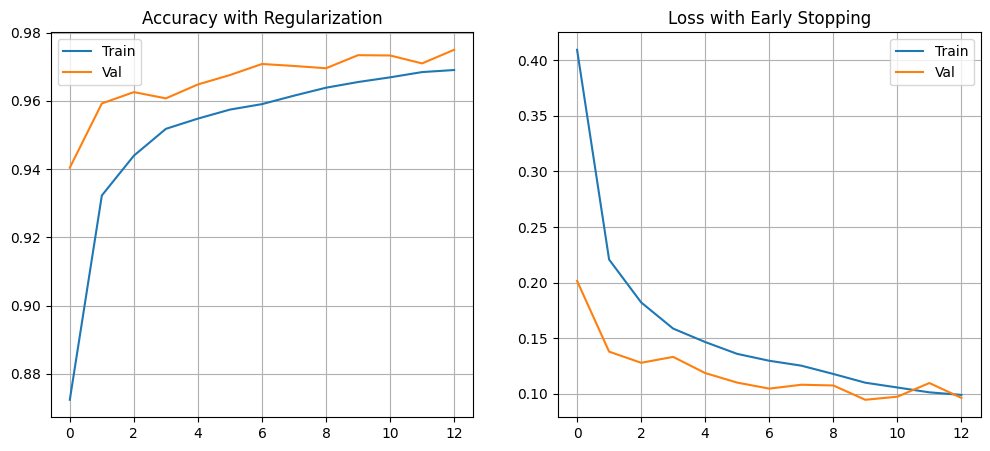

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# 1. Preprocessing with Validation Split
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
indices = list(range(len(full_train_dataset)))
split = int(0.2 * len(full_train_dataset)) # 20% validation split [cite: 311]
train_indices, val_indices = indices[split:], indices[:split]

train_loader = DataLoader(Subset(full_train_dataset, train_indices), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_train_dataset, val_indices), batch_size=32, shuffle=False)

# 2. Architecture with Dropout Regularization
class RegularizedMNIST(nn.Module):
    def __init__(self):
        super(RegularizedMNIST, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Dropout 20% of neurons to prevent overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2), # Second dropout layer
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.main(x)

model = RegularizedMNIST()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 3. Training with Early Stopping Logic
epochs = 50 # Set high, but Early Stopping will likely halt it sooner [cite: 411]
patience = 3 # Number of epochs to wait for improvement
best_val_loss = float('inf')
counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    t_loss, t_correct, t_total = 0, 0, 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        t_total += labels.size(0)
        t_correct += (pred == labels).sum().item()

    # Validation Phase
    model.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            v_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            v_total += labels.size(0)
            v_correct += (pred == labels).sum().item()

    avg_val_loss = v_loss / len(val_loader)
    history['train_loss'].append(t_loss/len(train_loader))
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(t_correct/t_total)
    history['val_acc'].append(v_correct/v_total)

    print(f"Epoch {epoch+1}: Val Loss: {avg_val_loss:.4f}, Val Acc: {v_correct/v_total:.4f}")

    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0 # Reset counter if improvement found
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# 4. Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.plot(history['train_acc'], label='Train'); plt.plot(history['val_acc'], label='Val')
plt.title("Accuracy with Regularization"); plt.legend(); plt.grid()
plt.subplot(1, 2, 2); plt.plot(history['train_loss'], label='Train'); plt.plot(history['val_loss'], label='Val')
plt.title("Loss with Early Stopping"); plt.legend(); plt.grid()
plt.show()